# **🌀 Clusterización con DBSCAN en datos reales (`digits` + PCA + t-SNE)**


### **🧠 Introducción**

En este notebook exploraremos el algoritmo de clusterización **DBSCAN** (*Density-Based Spatial Clustering of Applications with Noise*), aplicado a un conjunto de datos **real**: el dataset `digits` de `sklearn`, que contiene imágenes de dígitos manuscritos (0–9).

A diferencia de algoritmos como **K-Means**, que suponen clusters aproximadamente esféricos y requieren definir el número de clusters $K$, **DBSCAN**:

- No necesita especificar el número de clusters.
- Encuentra clusters de **formas arbitrarias**.
- Identifica puntos de **ruido** o valores atípicos (etiquetados como $-1$).
- Se basa en la idea de **densidad de puntos** en el espacio.

En este notebook haremos el siguiente recorrido:

1. Carga del dataset real `digits`.  
2. Reducción de dimensionalidad inicial con **PCA**.  
3. Reducción a 2 dimensiones con **t-SNE** para visualizar estructuras complejas.  
4. Aplicación de **DBSCAN** sobre el espacio 2D.  
5. Visualización de los clusters encontrados y el ruido.  
6. Breve comparación con K-Means y conclusiones.  

---

### **📐 Idea básica de DBSCAN**

DBSCAN se basa en dos parámetros:

- $\varepsilon$ (eps): radio de vecindad.  
- $\text{min\_samples}$: número mínimo de puntos dentro del radio $\varepsilon$ para considerar un punto como **núcleo**.

Con estos conceptos:

- **Punto núcleo**: tiene al menos $\text{min\_samples}$ vecinos dentro de distancia $\varepsilon$.  
- **Punto borde**: no es núcleo, pero está dentro de la vecindad de un núcleo.  
- **Punto ruido**: no es núcleo ni borde.  

Los clusters se forman conectando puntos núcleo que están densamente conectados entre sí.

---



### **📦 1. Carga del dataset `digits`**

Usaremos el dataset `digits` de `sklearn`, que contiene imágenes de dígitos de tamaño $8 \times 8$ (64 características por observación).  
Cada observación es un vector en un espacio de dimensión 64, junto con su etiqueta de dígito real (0–9).

A continuación:

- Cargaremos el dataset.  
- Crearemos un `DataFrame` opcionalmente para inspección.  
- Veremos la forma de los datos.  


In [ ]:
# Cargar el dataset digits
from sklearn.datasets import load_digits
import pandas as pd

digits = load_digits()
X = digits.data       # 64 características (8x8 píxeles)
y = digits.target     # dígito real (0-9)

print("Shape de X:", X.shape)
print("Shape de y:", y.shape)

# Opcional: convertir a DataFrame para inspeccionar
df_digits = pd.DataFrame(X)
df_digits['target'] = y
df_digits.head()

Shape de X: (1797, 64)
Shape de y: (1797,)


,0,1,2,3,4,5,6,7,8,9,...,55,56,57,58,59,60,61,62,63,target
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4



---

### **⚙️ 2. Preprocesamiento y reducción de dimensionalidad con PCA**

Trabajar directamente en 64 dimensiones puede ser costoso y difícil de visualizar.  
Primero aplicaremos **PCA** como reducción preliminar:

- Estandarizaremos los datos.  
- Aplicaremos PCA para reducir de 64 dimensiones a, por ejemplo, **30 componentes principales**.  
- Veremos cuánta **varianza acumulada** explican estos componentes.

La estandarización consiste en transformar cada variable según:

$z = \dfrac{x - \mu}{\sigma}$

donde $\mu$ es la media y $\sigma$ la desviación estándar de cada característica.


Shape después de PCA: (1797, 30)


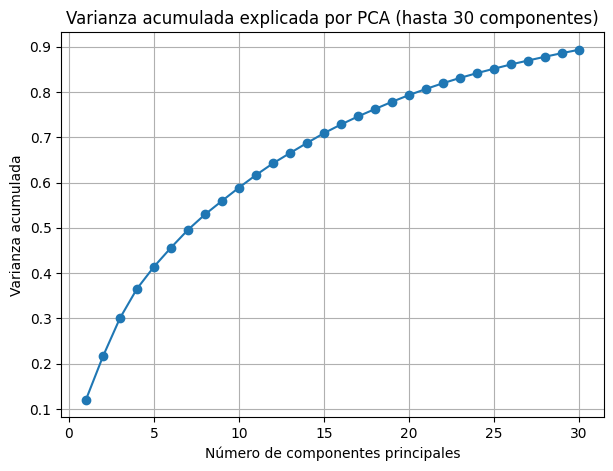

In [ ]:
# Estandarización y PCA preliminar
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

# Estandarizar datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Aplicar PCA para reducir a 30 componentes
pca = PCA(n_components=30, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Shape después de PCA:", X_pca.shape)

# Varianza explicada acumulada
var_exp = pca.explained_variance_ratio_
cum_var_exp = np.cumsum(var_exp)

plt.figure(figsize=(7,5))
plt.plot(range(1, len(cum_var_exp)+1), cum_var_exp, marker='o')
plt.title("Varianza acumulada explicada por PCA (hasta 30 componentes)")
plt.xlabel("Número de componentes principales")
plt.ylabel("Varianza acumulada")
plt.grid(True)
plt.show()


---

### **🧭 3. Reducción a 2D con t-SNE**

Para visualizar estructuras complejas y formas no lineales en los datos, utilizaremos **t-SNE** para proyectar los datos (ya reducidos con PCA) a 2 dimensiones.

Pasos:

- Usar como entrada $X_{PCA}$ (30 componentes).  
- Obtener un embedding 2D con t-SNE.  
- Visualizar el resultado coloreando por el dígito real para entender la estructura.  


In [ ]:
# Aplicar t-SNE sobre el resultado de PCA
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate='auto',
    init='pca',
    random_state=42
)

X_tsne = tsne.fit_transform(X_pca)
X_tsne[:5]

array([[-35.863472 , -31.447958 ],
       [-13.784933 ,  -2.564105 ],
       [ -5.621154 ,  -1.3250202],
       [ 33.23859  ,   6.3355703],
       [-37.17471  ,   2.1968129]], dtype=float32)


### **👀 4. Visualización preliminar del embedding t-SNE**

Visualizaremos los datos en 2D coloreando cada punto según su dígito real ($0$–$9$).  
Esto nos permitirá ver si los dígitos forman grupos separados, mezclas, o formas extrañas en el plano.



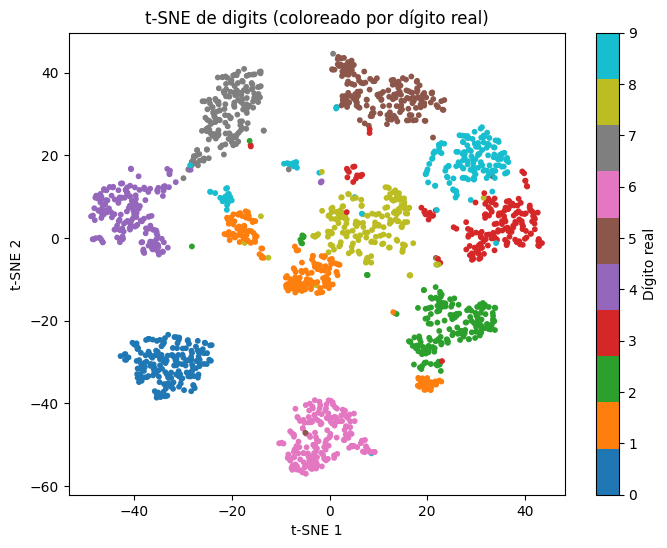

In [ ]:
# Visualización del embedding t-SNE coloreado por la etiqueta real
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap="tab10", s=10)
plt.title("t-SNE de digits (coloreado por dígito real)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.colorbar(scatter, label="Dígito real")
plt.show()


---

### **🌀 5. Aplicación de DBSCAN en el espacio 2D**

Ahora aplicaremos **DBSCAN** sobre las coordenadas 2D generadas por t-SNE.

Recordemos que DBSCAN requiere:

- $\varepsilon$ (`eps`): radio máximo para considerar vecinos.  
- $\text{min\_samples}$: mínimo número de puntos en el vecindario de un punto para ser un **punto núcleo**.

Pasos:

1. Aplicar DBSCAN sobre `X_tsne`.  
2. Inspeccionar las etiquetas: los puntos con etiqueta `-1` son ruido.  
3. Contar cuántos clusters encontró DBSCAN (ignorando el ruido).  


In [ ]:
labels_db

array([0, 1, 2, ..., 2, 5, 2])

In [ ]:
# Aplicar DBSCAN sobre el embedding 2D
from sklearn.cluster import DBSCAN

# Puedes ajustar eps y min_samples según la dispersión de los datos
dbscan = DBSCAN(eps = 3.2, min_samples=10)
labels_db = dbscan.fit_predict(X_tsne)

# Etiquetas encontradas
unique_labels = set(labels_db)
print("Etiquetas encontradas por DBSCAN:", unique_labels)

# Número de clusters (ignorando el ruido -1)
n_clusters = len([lab for lab in unique_labels if lab != -1])
n_noise = list(labels_db).count(-1)

print("Número de clusters (sin contar ruido):", n_clusters)
print("Número de puntos de ruido:", n_noise)

Etiquetas encontradas por DBSCAN: {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(-1)}
Número de clusters (sin contar ruido): 11
Número de puntos de ruido: 43



### **🎨 6. Visualización de los clusters encontrados por DBSCAN**

Visualizaremos ahora:

- Cada punto coloreado según el cluster asignado por DBSCAN.  
- Los puntos de ruido (etiqueta $-1$) aparecerán en un color separado.



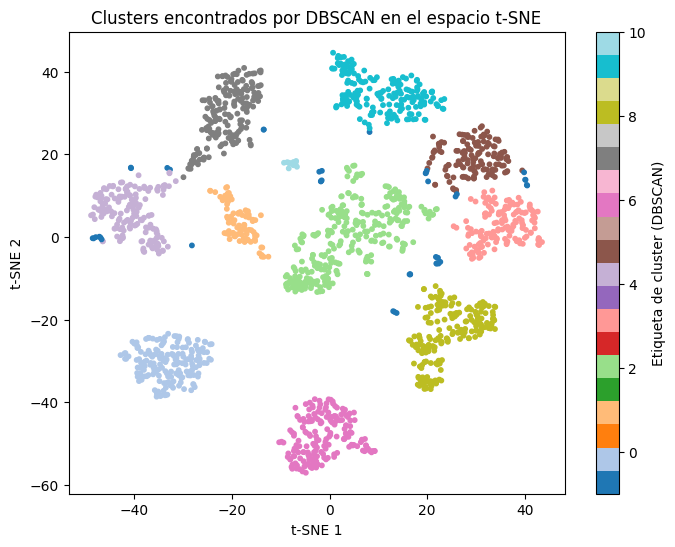

In [ ]:
# Visualización de clusters DBSCAN
plt.figure(figsize=(8,6))

# Elegir una paleta de colores
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels_db, cmap="tab20", s=10)
plt.title("Clusters encontrados por DBSCAN en el espacio t-SNE")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.colorbar(scatter, label="Etiqueta de cluster (DBSCAN)")
plt.show()


---

### **⚖️ 7. Comparación rápida con K-Means**

Para comparar enfoques, aplicaremos **K-Means** en el mismo espacio 2D y visualizaremos los resultados.

Recordemos que K-Means:

- Requiere especificar el número de clusters $K$ de antemano.  
- Tiende a buscar clusters aproximadamente esféricos.  

Aquí usaremos $K = 10$ (un cluster por dígito).  


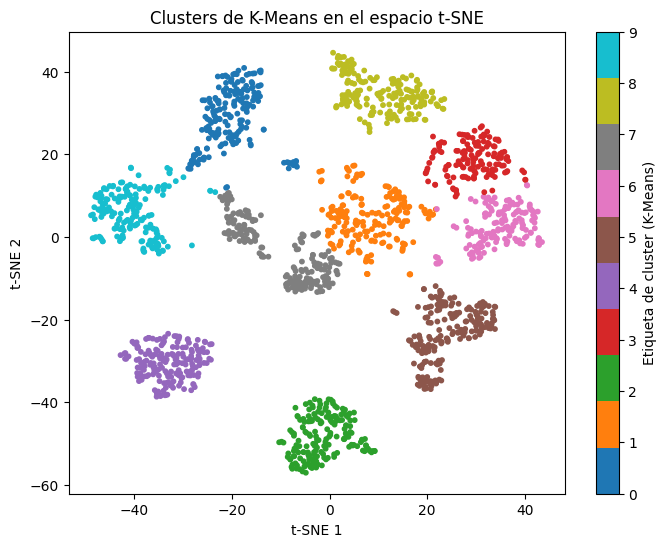

In [ ]:
# Comparación con K-Means en el espacio 2D
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=10, n_init=10, random_state=42)
labels_km = kmeans.fit_predict(X_tsne)

plt.figure(figsize=(8,6))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels_km, cmap="tab10", s=10)
plt.title("Clusters de K-Means en el espacio t-SNE")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.colorbar(scatter, label="Etiqueta de cluster (K-Means)")
plt.show()


---

### **🧭 8. Conclusiones**

En este notebook vimos:

- Cómo un dataset real de imágenes de dígitos puede representarse en un espacio 2D usando **PCA + t-SNE**.  
- Que las formas en el plano no son necesariamente esféricas, lo que hace que algoritmos como **K-Means** no siempre sean los más adecuados.  
- Cómo **DBSCAN** puede:

  - Detectar **clusters de formas arbitrarias**.  
  - Identificar puntos de **ruido** (etiqueta $-1$).  
  - Trabajar sin conocer el número de clusters de antemano.  

**Ideas para seguir experimentando:**

- Ajustar los hiperparámetros `eps` y `min_samples` y ver cómo cambian los clusters.  
- Probar DBSCAN directamente en el espacio PCA en lugar de t-SNE.  
- Comparar métricas de calidad de cluster (por ejemplo, silhouette score) entre DBSCAN y K-Means.  

✨ En resumen, **DBSCAN** es especialmente útil cuando sospechamos que los datos forman estructuras complejas y contienen ruido, como suele ocurrir en escenarios del mundo real.
